In [18]:
# %% Cell 0: Imports and paths
import os, pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex

BASE_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
CAMELS_FULL = f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
OUTPUT_ROOT = f'{BASE_PATH}/Output'
OUT_DIR_SUB = f'{OUTPUT_ROOT}/all_chile_results_v2'
NESTED_CSV_PATH = f'{OUT_DIR_SUB}/spatial_join_nested.csv'

print(f'Bounds shapefile exists: {os.path.exists(BOUNDS_PATH)}')
print(f'RESULTS.pkl exists: {os.path.exists(f"{OUT_DIR_SUB}/RESULTS.pkl")}')

Bounds shapefile exists: True
RESULTS.pkl exists: True


In [19]:
# %% Cell 1: Load basins, glacier area, RESULTS, country borders
with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)
print(f'RESULTS loaded: {len(RESULTS["CR2MET"])} gauges (CR2MET)')

bounds_all = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds_all['gauge_id'] = bounds_all['gauge_id'].astype(str)

nested_csv = pd.read_csv(NESTED_CSV_PATH, dtype={'gauge_id': str})
glacier_area_by_gauge = nested_csv.groupby('gauge_id')['Area'].sum().to_dict()
all_glacierized_basins_ever = set(
    gid for gid, area in glacier_area_by_gauge.items() if area > 0)

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile = world[world['NAME'] == 'Chile']
    arg = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception as e:
    print(f'Could not load country borders: {e}')
    has_borders = False

print(f'Basins loaded: {len(bounds_all)}')
print(f'Glacierized basins nationally: {len(all_glacierized_basins_ever)}')

RESULTS loaded: 143 gauges (CR2MET)
Basins loaded: 516
Glacierized basins nationally: 266


In [20]:
# %% Cell 2: Containment check
geoms = bounds_all.geometry.values
ids = bounds_all['gauge_id'].values
names = bounds_all['gauge_name'].values
areas = bounds_all['area_km2'].values

contained_map = {}
for i in range(len(bounds_all)):
    contained_ids = []
    for j in range(len(bounds_all)):
        if i == j or areas[i] <= areas[j]:
            continue
        overlap = geoms[i].intersection(geoms[j]).area
        if geoms[j].area > 0 and overlap / geoms[j].area > 0.9:
            contained_ids.append(ids[j])
    contained_map[ids[i]] = contained_ids

container_map = {gid: [] for gid in ids}
for parent_id, children in contained_map.items():
    for child_id in children:
        container_map[child_id].append(parent_id)

print('Cell 2 complete: containment maps built')

Cell 2 complete: containment maps built


In [21]:
# %% Cell 3: Assign nesting depth to every basin
def get_immediate_parent(gid):
    containers = container_map.get(gid, [])
    if not containers:
        return None
    containers_with_area = [
        (cid, areas[list(ids).index(cid)]) for cid in containers
    ]
    containers_with_area.sort(key=lambda x: x[1])
    return containers_with_area[0][0]

def get_full_chain(gid):
    chain = [gid]
    current = gid
    seen = {gid}
    while True:
        parent = get_immediate_parent(current)
        if parent is None or parent in seen:
            break
        chain.append(parent)
        seen.add(parent)
        current = parent
    return chain

basin_depth = {}
basin_immediate_parent = {}
basin_major_basin = {}

for gid in ids:
    chain = get_full_chain(gid)
    basin_depth[gid] = len(chain) - 1
    basin_immediate_parent[gid] = chain[1] if len(chain) > 1 else None
    basin_major_basin[gid] = chain[-1]

df_hierarchy = pd.DataFrame({
    'gauge_id': list(basin_depth.keys()),
    'depth': list(basin_depth.values()),
})
df_hierarchy['gauge_name'] = df_hierarchy['gauge_id'].map(dict(zip(ids, names)))
df_hierarchy['area_km2'] = df_hierarchy['gauge_id'].map(dict(zip(ids, areas)))
df_hierarchy['immediate_parent'] = df_hierarchy['gauge_id'].map(basin_immediate_parent)
df_hierarchy['major_basin_id'] = df_hierarchy['gauge_id'].map(basin_major_basin)
df_hierarchy['major_basin_name'] = df_hierarchy['major_basin_id'].map(dict(zip(ids, names)))
df_hierarchy['glacier_area_km2'] = df_hierarchy['gauge_id'].map(
    lambda g: glacier_area_by_gauge.get(g, 0))
df_hierarchy['glacier_pct'] = (df_hierarchy['glacier_area_km2'] /
                               df_hierarchy['area_km2'] * 100)

print('Nesting depth distribution (0 = top-level/major basin):')
print(df_hierarchy['depth'].value_counts().sort_index())
print(f'\nMax nesting depth found: {df_hierarchy["depth"].max()}')

df_hierarchy.to_csv(f'{OUTPUT_ROOT}/basin_hierarchy_full.csv', index=False)
print(f'Saved: {OUTPUT_ROOT}/basin_hierarchy_full.csv')

Nesting depth distribution (0 = top-level/major basin):
depth
0     101
1     108
2      95
3      75
4      45
5      33
6      18
7      16
8      12
9       6
10      4
11      1
12      1
13      1
Name: count, dtype: int64

Max nesting depth found: 13
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/basin_hierarchy_full.csv


In [22]:
# %% Cell 4: Data quality flagging
def check_runoff_exceeds_q(gid, dataset='CR2MET'):
    res = RESULTS[dataset].get(gid)
    if res is None:
        return None
    m = res['monthly'].copy()
    m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
    if len(m) == 0:
        return None
    m['pct'] = m['glacier_runoff_m3'] / m['q_m3_mon'] * 100
    return {
        'n_months': len(m),
        'n_months_over_100': (m['pct'] > 100).sum(),
        'pct_months_over_100': (m['pct'] > 100).mean() * 100,
        'median_pct': m['pct'].median(),
        'max_pct': m['pct'].max(),
    }

quality_records = []
for gid in all_glacierized_basins_ever:
    if gid not in RESULTS['CR2MET']:
        continue
    result = check_runoff_exceeds_q(gid)
    if result is None:
        continue
    name = dict(zip(ids, names)).get(gid, '?')
    quality_records.append({'gauge_id': gid, 'gauge_name': name, **result})

df_quality = pd.DataFrame(quality_records).sort_values(
    'pct_months_over_100', ascending=False)

print('Data quality flags: basins where glacier runoff exceeds Q')
print(df_quality.head(25).to_string(index=False))

QUALITY_FLAG_THRESHOLD = 20.0
flagged_basins = set(
    df_quality[df_quality['pct_months_over_100'] > QUALITY_FLAG_THRESHOLD]['gauge_id'])
print(f'\nBasins flagged (>{QUALITY_FLAG_THRESHOLD}% of months with runoff>Q): '
      f'{len(flagged_basins)}')
print(f'Flagged: {flagged_basins}')

df_quality.to_csv(f'{OUTPUT_ROOT}/basin_data_quality_flags.csv', index=False)

Data quality flags: basins where glacier runoff exceeds Q
gauge_id                                  gauge_name  n_months  n_months_over_100  pct_months_over_100   median_pct      max_pct
 7317003                 Rio Melado En Zona De Presa       199                107            53.768844 2.154615e+02 69191.958960
 5406001                    Rio Colorado En Colorado       206                 87            42.233010 5.675125e+01 27263.759403
 6008005    Rio Cachapoal En Pte Termas De Cauquenes       190                 65            34.210526 6.519751e+01  2603.588778
 7321002                      Rio Maule En Armerillo       197                 65            32.994924 1.324780e+01   849.418806
 7306001 Rio Cipreses En Dasague Laguna La Invernada       172                 48            27.906977 8.594820e+00   353.659743
 5706001       Rio Olivares Antes Junta Rio Colorado       222                 59            26.576577 6.590002e+00   991.761563
 3022001                     Rio La Ola

In [23]:
# Characterize what the 9 flagged basins have in common

flagged_detail = df_hierarchy[df_hierarchy['gauge_id'].isin(flagged_basins)]
print(flagged_detail[['gauge_id','gauge_name','depth','area_km2','glacier_pct']]
      .sort_values('glacier_pct', ascending=False).to_string(index=False))

print(f'\nMedian glacier_pct, flagged basins: {flagged_detail["glacier_pct"].median():.2f}%')
print(f'Median glacier_pct, all glacierized basins: '
      f'{df_hierarchy[df_hierarchy["gauge_id"].isin(all_glacierized_basins_ever)]["glacier_pct"].median():.2f}%')
print(f'\nMedian nesting depth, flagged basins: {flagged_detail["depth"].median()}')
print(f'Median nesting depth, all glacierized basins: '
      f'{df_hierarchy[df_hierarchy["gauge_id"].isin(all_glacierized_basins_ever)]["depth"].median()}')

gauge_id                                  gauge_name  depth     area_km2  glacier_pct
 5706001       Rio Olivares Antes Junta Rio Colorado      3   541.555296    14.624730
 6008005    Rio Cachapoal En Pte Termas De Cauquenes      1  2461.609525     7.962717
 5406001                    Rio Colorado En Colorado      6  1140.925476     4.304137
 1020003               Rio Lauca En Estancia El Lago      1   582.938351     1.198240
 7317003                 Rio Melado En Zona De Presa      3  2269.444198     0.941508
 7321002                      Rio Maule En Armerillo      2  5468.959398     0.554658
 3022001                     Rio La Ola En Vertedero      0 12310.980090     0.539965
 3430001                      Rio Copiapo En Lautaro      6  7568.166065     0.455474
 7306001 Rio Cipreses En Dasague Laguna La Invernada      4   867.527580     0.157344

Median glacier_pct, flagged basins: 0.94%
Median glacier_pct, all glacierized basins: 0.56%

Median nesting depth, flagged basins: 3.0
Medi

In [24]:
# Check whether flagged basins' runoff>Q events cluster in irrigation
# season months, supporting a water-extraction explanation

for gid in flagged_basins:
    res = RESULTS['CR2MET'].get(gid)
    if res is None:
        continue
    m = res['monthly'].copy()
    m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
    m['pct'] = m['glacier_runoff_m3'] / m['q_m3_mon'] * 100
    over100 = m[m['pct'] > 100]
    name = bounds_all[bounds_all['gauge_id']==gid]['gauge_name'].values[0]
    if len(over100) == 0:
        continue
    month_counts = over100['month'].value_counts().sort_index()
    print(f'{gid} ({name}): month distribution of runoff>Q events:')
    print(f'  {dict(month_counts)}')
    print()

6008005 (Rio Cachapoal En Pte Termas De Cauquenes): month distribution of runoff>Q events:
  {1: 5, 2: 10, 3: 15, 4: 15, 5: 9, 6: 1, 7: 1, 8: 2, 9: 1, 10: 4, 11: 2}

5406001 (Rio Colorado En Colorado): month distribution of runoff>Q events:
  {1: 13, 2: 18, 3: 18, 4: 16, 5: 9, 6: 4, 7: 2, 8: 1, 11: 1, 12: 5}

7306001 (Rio Cipreses En Dasague Laguna La Invernada): month distribution of runoff>Q events:
  {1: 10, 2: 12, 3: 13, 4: 5, 11: 1, 12: 7}

3430001 (Rio Copiapo En Lautaro): month distribution of runoff>Q events:
  {1: 18, 2: 15, 3: 10, 4: 5, 12: 7}

1020003 (Rio Lauca En Estancia El Lago): month distribution of runoff>Q events:
  {1: 12, 2: 13, 3: 8, 11: 4, 12: 16}

7317003 (Rio Melado En Zona De Presa): month distribution of runoff>Q events:
  {1: 15, 2: 17, 3: 17, 4: 16, 5: 12, 10: 6, 11: 10, 12: 14}

5706001 (Rio Olivares Antes Junta Rio Colorado): month distribution of runoff>Q events:
  {1: 13, 2: 16, 3: 19, 4: 3, 12: 8}

7321002 (Rio Maule En Armerillo): month distribution o

In [25]:
# %% Cell 5: Compute glacier fraction at EVERY nesting level, for every
# glacierized leaf basin's full chain. NOTE: flagged basins are included
# in the computation, only visually distinguished later (not excluded).

def basin_fraction(gid, dataset='CR2MET', months=None):
    res = RESULTS[dataset].get(gid)
    if res is None:
        return np.nan
    m = res['monthly'].copy()
    if months is not None:
        m = m[m['month'].isin(months)]
    m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
    if len(m) == 0:
        return np.nan
    return (m['glacier_runoff_m3'].sum() / m['q_m3_mon'].sum()) * 100

leaf_ids_v3 = set()
for gid in all_glacierized_basins_ever:
    children = contained_map.get(gid, [])
    glacierized_children = [c for c in children if glacier_area_by_gauge.get(c, 0) > 0]
    if len(glacierized_children) == 0 and gid in RESULTS['CR2MET']:
        leaf_ids_v3.add(gid)

print(f'Glacierized leaf basins: {len(leaf_ids_v3)}')
print(f'Of which flagged for data quality (included, not excluded): '
      f'{len(leaf_ids_v3 & flagged_basins)}')

chain_records = []
for leaf_gid in leaf_ids_v3:
    chain = get_full_chain(leaf_gid)
    n_levels = len(chain)
    for depth_idx, gid in enumerate(chain):
        row = bounds_all[bounds_all['gauge_id']==gid]
        if len(row) == 0:
            continue
        area = row['area_km2'].values[0]
        name = row['gauge_name'].values[0]
        frac = basin_fraction(gid)
        chain_records.append({
            'leaf_gauge_id': leaf_gid,
            'leaf_gauge_name': bounds_all[bounds_all['gauge_id']==leaf_gid]['gauge_name'].values[0],
            'chain_position': depth_idx,
            'chain_length': n_levels,
            'is_leaf': depth_idx == 0,
            'is_major': depth_idx == n_levels - 1,
            'gauge_id': gid, 'gauge_name': name, 'area_km2': area,
            'annual_fraction_pct': frac,
            'leaf_flagged': leaf_gid in flagged_basins,
        })

df_chains = pd.DataFrame(chain_records)
df_chains.to_csv(f'{OUTPUT_ROOT}/basin_chain_fractions.csv', index=False)
print(f'\nChain records built: {len(df_chains)} (across {len(leaf_ids_v3)} leaf chains)')
print(df_chains.head(15).to_string(index=False))

Glacierized leaf basins: 54
Of which flagged for data quality (included, not excluded): 2

Chain records built: 239 (across 54 leaf chains)
leaf_gauge_id               leaf_gauge_name  chain_position  chain_length  is_leaf  is_major gauge_id                            gauge_name     area_km2  annual_fraction_pct  leaf_flagged
     11514001    Rio Murta En Desembocadura               0             5     True     False 11514001            Rio Murta En Desembocadura   897.136309            14.066755         False
     11514001    Rio Murta En Desembocadura               1             5    False     False 11530000    Rio Baker En Desague Lago Bertrand 15997.702539            19.255766         False
     11514001    Rio Murta En Desembocadura               2             5    False     False 11536004      Rio Baker En Angostura Chacabuco 16793.405545            16.544588         False
     11514001    Rio Murta En Desembocadura               3             5    False     False 11542001       

In [26]:
# # %% Cell 6: Dilution visualization
# fig, ax = plt.subplots(figsize=(11, 8))

# clean_chains = df_chains[~df_chains['leaf_flagged']]
# flagged_chains = df_chains[df_chains['leaf_flagged']]

# leaf_glacier_pct = {
#     gid: glacier_area_by_gauge.get(gid, 0) /
#          bounds_all[bounds_all['gauge_id']==gid]['area_km2'].values[0] * 100
#     for gid in leaf_ids_v3
#     if len(bounds_all[bounds_all['gauge_id']==gid]) > 0
# }
# max_pct = max(leaf_glacier_pct.values()) if leaf_glacier_pct else 1
# cmap = plt.cm.viridis
# norm = Normalize(vmin=0, vmax=max_pct)

# for leaf_gid in clean_chains['leaf_gauge_id'].unique():
#     sub = clean_chains[clean_chains['leaf_gauge_id']==leaf_gid].sort_values('chain_position')
#     sub = sub.dropna(subset=['annual_fraction_pct'])
#     if len(sub) < 2:
#         continue
#     color = cmap(norm(leaf_glacier_pct.get(leaf_gid, 0)))
#     ax.plot(sub['chain_position'], sub['annual_fraction_pct'],
#            'o-', color=color, alpha=0.6, lw=1, ms=3)

# for leaf_gid in flagged_chains['leaf_gauge_id'].unique():
#     sub = flagged_chains[flagged_chains['leaf_gauge_id']==leaf_gid].sort_values('chain_position')
#     sub = sub.dropna(subset=['annual_fraction_pct'])
#     if len(sub) < 2:
#         continue
#     ax.plot(sub['chain_position'], sub['annual_fraction_pct'],
#            'o--', color='grey', alpha=0.4, lw=1, ms=3,
#            label='Data-quality flagged' if leaf_gid == list(flagged_chains['leaf_gauge_id'].unique())[0] else None)

# sm = ScalarMappable(cmap=cmap, norm=norm)
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Leaf basin glacier area (%)', fontsize=9)

# ax.set_xlabel('Position in hierarchy chain (0 = smallest leaf basin, '
#              'increasing toward major basin)', fontsize=10)
# ax.set_ylabel('Glacier runoff as % of streamflow (annual)', fontsize=10)
# ax.set_title('Glacier Contribution Dilution: Source (leaf basins) to Sink (major basins)\n'
#              'Colored = clean chains | Grey dashed = data-quality flagged (included, not excluded)',
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(f'{OUTPUT_ROOT}/dilution_source_to_sink.png', dpi=150, bbox_inches='tight')
# plt.show()


In [27]:
import glob
possible_files = glob.glob(f'{BASE_PATH}/**/*erarquia*', recursive=True) + \
                  glob.glob(f'{OUTPUT_ROOT}/**/*main_basin*', recursive=True) + \
                  glob.glob(f'{OUTPUT_ROOT}/**/*for_alexis*', recursive=True)
print('Possible jerarquia/main-basin files found:')
for f in possible_files:
    print(f'  {f}')

Possible jerarquia/main-basin files found:
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2/camels_jerarquia_map.png
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.prj
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.sbn
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia_glaciar_RGI.shp.zip
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia_glaciar_RGI.prj
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia_glaciar_RGI.sbn
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.cpg
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.shp
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.sbx
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_jerarquia.shx
  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Camels_filtrado/Camels_je

In [28]:
import geopandas as gpd

CAMELS_FILTRADO = f'{BASE_PATH}/Camels_filtrado'

jerarquia = gpd.read_file(f'{CAMELS_FILTRADO}/Camels_jerarquia.shp')
print('Camels_jerarquia.shp columns:', list(jerarquia.columns))
print(f'Total basins: {len(jerarquia)}')
print(jerarquia.head())
print()

jerarquia_glaciar = gpd.read_file(f'{CAMELS_FILTRADO}/Camels_jerarquia_glaciar_RGI.shp')
print('Camels_jerarquia_glaciar_RGI.shp columns:', list(jerarquia_glaciar.columns))
print(f'Total rows: {len(jerarquia_glaciar)}')
print(jerarquia_glaciar.head())

Camels_jerarquia.shp columns: ['gauge_id', 'gauge_name', 'area_km2', 'id', 'jerarquia', 'geometry']
Total basins: 146
   gauge_id                          gauge_name     area_km2         id  \
0   1001002            Rio Caquena En Vertedero   467.556222  1001002.0   
1   1021001  Rio Lauca En Japu (O En El Limite)  3277.980908  1021001.0   
2   1041002              Rio Isluga En Bocatoma   654.506002  1041002.0   
3   1044001             Rio Cancosa En El Tambo   992.026305  1044001.0   
4   1050002              Rio Piga En Collacagua   391.225696  1050002.0   

   jerarquia                                           geometry  
0        0.0  POLYGON ((-69.14347 -18.15958, -69.14375 -18.1...  
1        0.0  POLYGON ((-69.40319 -18.18875, -69.40319 -18.1...  
2        0.0  POLYGON ((-68.97653 -19.32236, -68.97764 -19.3...  
3        0.0  POLYGON ((-68.75736 -20.08875, -68.75736 -20.0...  
4        0.0  POLYGON ((-68.79251 -19.80426, -68.79251 -19.8...  

Camels_jerarquia_glaciar_RGI.shp c

Chain records with NaN fraction (basin not in RESULTS): 72 of 239 (30.1%)


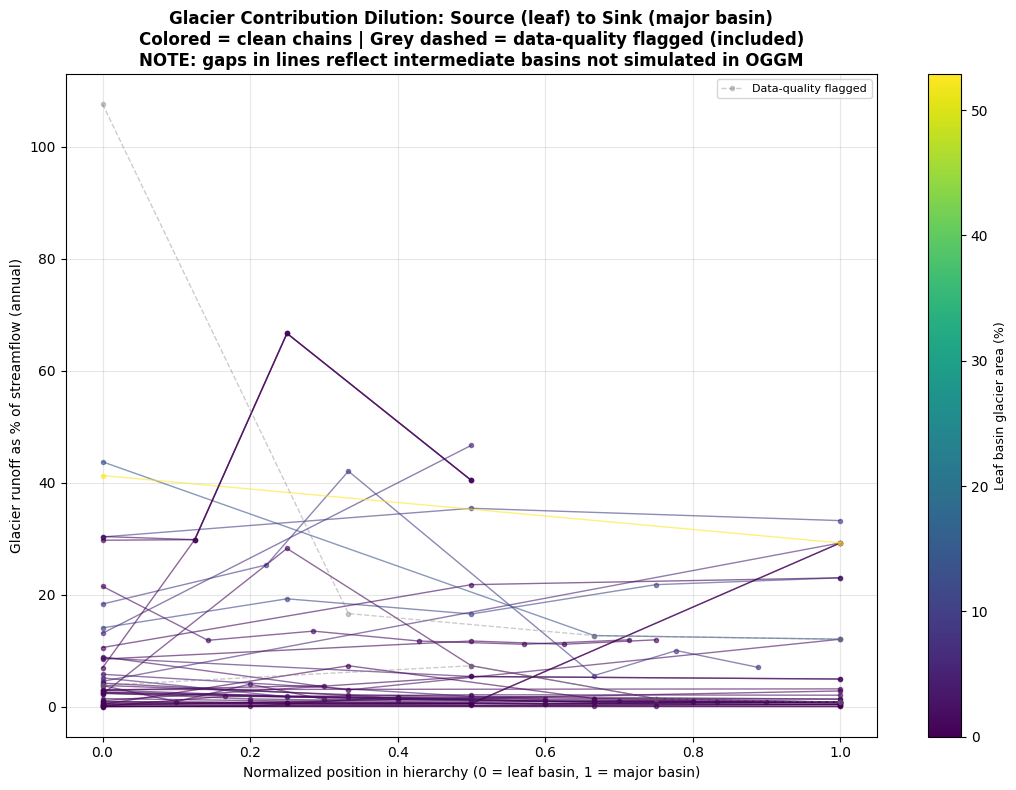

In [29]:
# ── Dilution visualization: normalized position (0=leaf, 1=major basin) ──
# NOTE: many intermediate chain steps will show NaN fraction, since only
# ~143 basins (those with meaningful glacier presence) were run through
# OGGM; non-glacierized pass-through basins in a chain were never
# simulated and have no glacier_runoff_m3/q_m3_mon data to compute from.

df_chains['normalized_position'] = df_chains.apply(
    lambda row: row['chain_position'] / (row['chain_length'] - 1)
    if row['chain_length'] > 1 else 0, axis=1)

n_nan = df_chains['annual_fraction_pct'].isna().sum()
print(f'Chain records with NaN fraction (basin not in RESULTS): '
      f'{n_nan} of {len(df_chains)} ({n_nan/len(df_chains)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(11, 8))

clean_chains = df_chains[~df_chains['leaf_flagged']]
flagged_chains = df_chains[df_chains['leaf_flagged']]

leaf_glacier_pct = {
    gid: glacier_area_by_gauge.get(gid, 0) /
         bounds_all[bounds_all['gauge_id']==gid]['area_km2'].values[0] * 100
    for gid in leaf_ids_v3
    if len(bounds_all[bounds_all['gauge_id']==gid]) > 0
}
max_pct = max(leaf_glacier_pct.values()) if leaf_glacier_pct else 1
cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=max_pct)

for leaf_gid in clean_chains['leaf_gauge_id'].unique():
    sub = clean_chains[clean_chains['leaf_gauge_id']==leaf_gid].sort_values('normalized_position')
    sub = sub.dropna(subset=['annual_fraction_pct'])
    if len(sub) < 2:
        continue
    color = cmap(norm(leaf_glacier_pct.get(leaf_gid, 0)))
    ax.plot(sub['normalized_position'], sub['annual_fraction_pct'],
           'o-', color=color, alpha=0.6, lw=1, ms=3)

first_flagged = True
for leaf_gid in flagged_chains['leaf_gauge_id'].unique():
    sub = df_chains[df_chains['leaf_gauge_id']==leaf_gid].sort_values('normalized_position')
    sub = sub.dropna(subset=['annual_fraction_pct'])
    if len(sub) < 2:
        continue
    ax.plot(sub['normalized_position'], sub['annual_fraction_pct'],
           'o--', color='grey', alpha=0.4, lw=1, ms=3,
           label='Data-quality flagged' if first_flagged else None)
    first_flagged = False

sm = ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Leaf basin glacier area (%)', fontsize=9)

ax.set_xlabel('Normalized position in hierarchy (0 = leaf basin, 1 = major basin)', fontsize=10)
ax.set_ylabel('Glacier runoff as % of streamflow (annual)', fontsize=10)
ax.set_title('Glacier Contribution Dilution: Source (leaf) to Sink (major basin)\n'
             'Colored = clean chains | Grey dashed = data-quality flagged (included)\n'
             'NOTE: gaps in lines reflect intermediate basins not simulated in OGGM',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/dilution_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

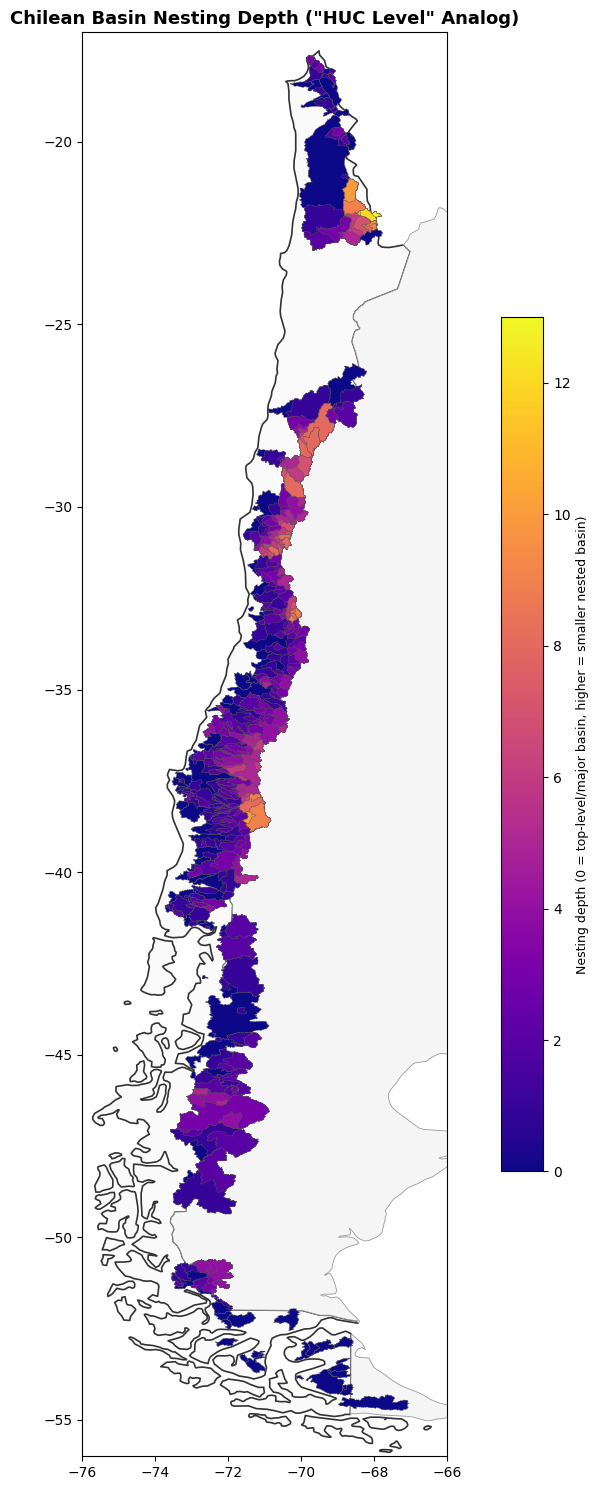

In [30]:
# %% Cell 7: Map — nesting depth across Chile
fig, ax = plt.subplots(figsize=(11, 15))
if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_depth = bounds_all.merge(df_hierarchy[['gauge_id','depth']], on='gauge_id', how='left')
bounds_depth = bounds_depth.sort_values('area_km2', ascending=False)

max_depth = bounds_depth['depth'].max()
depth_norm = Normalize(vmin=0, vmax=max_depth)
depth_cmap = plt.cm.plasma

bounds_depth.plot(ax=ax, column='depth', cmap=depth_cmap, norm=depth_norm,
                  edgecolor='#555555', linewidth=0.2, zorder=2)

sm = ScalarMappable(cmap=depth_cmap, norm=depth_norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Nesting depth (0 = top-level/major basin, higher = smaller nested basin)',
              fontsize=9)

ax.set_xlim(-76, -66)
ax.set_ylim(-56, -17)
ax.set_aspect('equal')
ax.set_title('Chilean Basin Nesting Depth ("HUC Level" Analog)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/nesting_depth_map.png', dpi=150, bbox_inches='tight')
plt.show()


Data quality reliability by nesting depth:
 depth  n_basins_total  n_glacierized  n_flagged  pct_flagged
     0             101             41          1     2.439024
     1             108             51          2     3.921569
     2              95             49          1     2.040816
     3              75             40          2     5.000000
     4              45             27          1     3.703704
     5              33             19          0     0.000000
     6              18             12          2    16.666667
     7              16              9          0     0.000000
     8              12              8          0     0.000000
     9               6              5          0     0.000000
    10               4              3          0     0.000000
    11               1              1          0     0.000000
    12               1              1          0     0.000000
    13               1              0          0          NaN


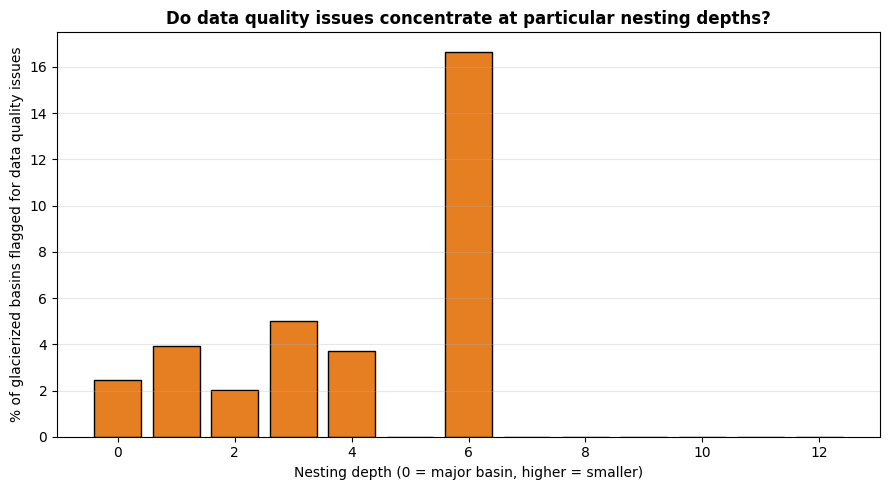


Notebook complete.


In [31]:
# %% Cell 8: Completeness/reliability by nesting depth
depth_reliability = []
for depth_level in sorted(df_hierarchy['depth'].unique()):
    basins_at_depth = set(df_hierarchy[df_hierarchy['depth']==depth_level]['gauge_id'])
    glacierized_at_depth = basins_at_depth & all_glacierized_basins_ever
    flagged_at_depth = glacierized_at_depth & flagged_basins
    n_glac = len(glacierized_at_depth)
    n_flagged = len(flagged_at_depth)
    depth_reliability.append({
        'depth': depth_level,
        'n_basins_total': len(basins_at_depth),
        'n_glacierized': n_glac,
        'n_flagged': n_flagged,
        'pct_flagged': (n_flagged/n_glac*100) if n_glac > 0 else np.nan,
    })

df_depth_reliability = pd.DataFrame(depth_reliability)
print('Data quality reliability by nesting depth:')
print(df_depth_reliability.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
valid = df_depth_reliability.dropna(subset=['pct_flagged'])
ax.bar(valid['depth'], valid['pct_flagged'], color='#e67e22', edgecolor='k')
ax.set_xlabel('Nesting depth (0 = major basin, higher = smaller)', fontsize=10)
ax.set_ylabel('% of glacierized basins flagged for data quality issues', fontsize=10)
ax.set_title('Do data quality issues concentrate at particular nesting depths?',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/reliability_by_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNotebook complete.')

In [32]:
import geopandas as gpd
import pandas as pd

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
FILTRADO    = f'{BASE}/Camels_filtrado'
BOUNDS_PATH = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
RGI_PATH    = (f'{BASE}/files_chile_OGGM_climate_comparison/'
               f'RGI_BNA_Clusters.csv')

GLAC_THRESHOLD_PCT = 1.0   # confirmed: sticking with 1%

bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
if bounds.crs.to_epsg() != 4326:
    bounds = bounds.to_crs(epsg=4326)

rgi = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi, geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat), crs='EPSG:4326')

hier = gpd.read_file(f'{FILTRADO}/Camels_jerarquia.shp')
hier['gauge_id'] = hier['gauge_id'].astype(str)
if hier.crs.to_epsg() != 4326:
    hier = hier.to_crs(epsg=4326)

print(f'Total CAMELS basins (all levels): {len(bounds)}')
print(f'Total jerarquia=0 main basins:    {len(hier[hier["jerarquia"]==0])}')

joined_all = gpd.sjoin(gdf_rgi, bounds, how='inner', predicate='within')
glacierized_all = set(joined_all['gauge_id'].unique())
print(f'\nOf all {len(bounds)} CAMELS basins, basins containing >=1 glacier: '
      f'{len(glacierized_all)}')

main_basins = hier[hier['jerarquia'] == 0].copy()
main_glacierized_ids = main_basins[
    main_basins['gauge_id'].isin(glacierized_all)]['gauge_id'].tolist()
print(f'Of {len(main_basins)} main (jerarquia=0) basins, '
      f'those containing >=1 glacier: {len(main_glacierized_ids)}')

glacier_stats = (joined_all.groupby('gauge_id')
                 .agg(n_glaciers=('RGIId','count'), glacier_area=('Area','sum'))
                 .reset_index())

main_utm = main_basins[main_basins['gauge_id'].isin(main_glacierized_ids)].copy()
main_utm = main_utm.to_crs(epsg=32719)
main_utm['basin_area_km2'] = main_utm.geometry.area / 1e6
main_utm = main_utm.merge(glacier_stats, on='gauge_id', how='left')
main_utm['glacier_pct'] = main_utm['glacier_area'] / main_utm['basin_area_km2'] * 100

before = len(main_utm)
main_final_1pct = main_utm[main_utm['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
after = len(main_final_1pct)

print(f'\n{"="*70}')
print(f'RESULT: applying {GLAC_THRESHOLD_PCT}% threshold to main (jerarquia=0) basins')
print(f'{"="*70}')
print(f'Main basins with ANY glacier (before threshold): {before}')
print(f'Main basins with >= {GLAC_THRESHOLD_PCT}% glacier (after threshold): {after}')
print(f'Removed by threshold: {before - after}')

print(f'\nFinal basin list ({after} basins):')
print(main_final_1pct[['gauge_id','gauge_name','basin_area_km2',
                        'glacier_area','glacier_pct']]
      .sort_values('glacier_pct', ascending=False).to_string(index=False))

main_final_1pct.to_csv(
    f'{BASE}/Output/main_basins_1pct_final_check.csv', index=False)
print(f'\nSaved: {BASE}/Output/main_basins_1pct_final_check.csv')

Total CAMELS basins (all levels): 516
Total jerarquia=0 main basins:    146

Of all 516 CAMELS basins, basins containing >=1 glacier: 266
Of 146 main (jerarquia=0) basins, those containing >=1 glacier: 61

RESULT: applying 1.0% threshold to main (jerarquia=0) basins
Main basins with ANY glacier (before threshold): 61
Main basins with >= 1.0% glacier (after threshold): 24
Removed by threshold: 37

Final basin list (24 basins):
gauge_id                                  gauge_name  basin_area_km2  glacier_area  glacier_pct
11130001        Rio Ventisquero En Carretera Austral      163.640398        57.284    35.006026
12288004               Rio Caadon 1 En Desembocadura      158.756493        38.571    24.295699
11711000            Rio Pascua Ante Junta Rio Quetru    14134.076009      2378.184    16.825889
12289001                Rio Serrano En Desembocadura     8583.255148       937.711    10.924888
11701001                  Rio Mayer En Desembocadura     5327.007211       509.350     9.5

In [33]:
import pickle
import numpy as np
import os

BASE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUT_DIR_SUB = f'{BASE}/Output/all_chile_results_v2'

with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)

print(f'RESULTS loaded: '
      f'{ {ds: len(RESULTS[ds]) for ds in RESULTS} }')

final_24 = main_final_1pct['gauge_id'].tolist()

print(f'\nGlacier fraction of streamflow, 1% main basins, all 3 datasets:')
print(f'{"gauge_id":12s} {"gauge_name":35s} '
      f'{"CR2MET":>8s} {"ERA5":>8s} {"CRU":>8s} {"in_RESULTS"}')
print('-'*90)

frac_summary = []
for gid in final_24:
    name_row = main_final_1pct[main_final_1pct['gauge_id']==gid]
    name = name_row['gauge_name'].values[0]

    row_out = {'gauge_id': gid, 'gauge_name': name}
    in_results = {}
    for ds in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS.get(ds, {}).get(gid)
        in_results[ds] = res is not None
        if res is None:
            row_out[ds] = np.nan
            continue
        m = res['monthly']
        m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
        if len(m) == 0:
            row_out[ds] = np.nan
            continue
        row_out[ds] = (m['glacier_runoff_m3'].sum() / m['q_m3_mon'].sum()) * 100

    frac_summary.append(row_out)
    flags = ''.join(ds[0] if in_results[ds] else '-' for ds in ['CR2MET','ERA5','CRU'])
    print(f'{gid:12s} {name[:33]:35s} '
          f'{row_out["CR2MET"]:8.2f} {row_out["ERA5"]:8.2f} {row_out["CRU"]:8.2f}  {flags}')

df_frac_summary = pd.DataFrame(frac_summary)
df_frac_summary.to_csv(f'{BASE}/Output/main_basins_1pct_3dataset_fractions.csv', index=False)
print(f'\nSaved: {BASE}/Output/main_basins_1pct_3dataset_fractions.csv')

n_all_three = sum(1 for r in frac_summary if not any(pd.isna(r[ds]) for ds in ['CR2MET','ERA5','CRU']))
print(f'\nBasins with valid fraction in all 3 datasets: {n_all_three} of {len(final_24)}')

RESULTS loaded: {'CR2MET': 143, 'ERA5': 143, 'CRU': 143}

Glacier fraction of streamflow, 1% main basins, all 3 datasets:
gauge_id     gauge_name                            CR2MET     ERA5      CRU in_RESULTS
------------------------------------------------------------------------------------------
3041005      Rio Lamas En El Salto                    nan      nan      nan  ---
5707002      Rio Colorado Antes Junta Rio Maip      16.62    21.40    14.95  CEC
5710001      Rio Maipo En El Manzano                12.69    14.86     9.29  CEC
5721001      Estero Yerba Loca Antes Junta San       8.89    11.08     7.61  CEC
5748001      Rio Maipo En Cabimbao                  12.04    13.81     8.80  CEC
6019003      Rio Cachapoal En Puente Arqueado         nan      nan      nan  ---
6034001      Estero Chimbarongo En Santa Cruz         nan      nan      nan  ---
6035001      Rio Tinguiririca En Los Olmos (Ca       5.32     4.89     3.25  CEC
9404001      Rio Allipen En Los Laureles            

In [34]:
# Diagnose WHY these 8 basins are missing from RESULTS: were their
# glaciers ever simulated by OGGM at all, or were they simulated but
# never carried into the RESULTS.pkl comparison step?

missing_8 = ['3041005', '6019003', '6034001', '11130001',
            '11147001', '11151001', '11405001', '12288004']

BASE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT = f'{BASE}/Output'
CLUSTERS = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']

print('Diagnosing 8 missing basins')
print('='*100)

for gid in missing_8:
    row = main_final_1pct[main_final_1pct['gauge_id']==gid]
    if len(row) == 0:
        print(f'{gid}: not found in main_final_1pct at all (unexpected)')
        continue
    name = row['gauge_name'].values[0]
    glac_area = row['glacier_area'].values[0]

    # Which RGI glaciers does this basin contain, and which cluster(s)?
    matched_rgi = joined_all[joined_all['gauge_id']==gid]
    clusters_involved = sorted(matched_rgi['Cluster'].unique().tolist()) \
        if 'Cluster' in matched_rgi.columns else []
    n_glaciers = len(matched_rgi)

    print(f'\n{gid} ({name})')
    print(f'  Glacier area: {glac_area:.2f} km2, {n_glaciers} glaciers, '
          f'clusters: {clusters_involved}')

    # Step 1: does mb.csv exist for these clusters (= OGGM ran the glaciers)?
    for cl in clusters_involved:
        mb_file = f'{OUTPUT_ROOT}/CR2MET/{cl}/mb.csv'
        mb_exists = os.path.exists(mb_file)
        n_in_mb = 0
        if mb_exists:
            mb_df = pd.read_csv(mb_file)
            rgi_ids_here = matched_rgi[matched_rgi['Cluster']==cl]['RGIId'].tolist()
            id_col = 'rgi_id' if 'rgi_id' in mb_df.columns else mb_df.columns[0]
            n_in_mb = mb_df[mb_df[id_col].isin(rgi_ids_here)].shape[0]
        print(f'    Cluster {cl}: mb.csv exists={mb_exists}, '
              f'glaciers from this basin found in mb.csv={n_in_mb}')

    # Step 2: does this gauge have a streamflow record in CAMELS at all?
    q_col_exists = None
    try:
        q_mon = pd.read_csv(f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/q_m3s_mon.csv',
                            nrows=1)
        q_col_exists = gid in q_mon.columns
    except Exception as e:
        q_col_exists = f'error checking: {e}'
    print(f'  Has a Q column in CAMELS q_m3s_mon.csv: {q_col_exists}')

    # Step 3: is this basin in the completeness-passing set at all
    # (i.e. GAUGE_INFO_FRAC from the main 137-basin pipeline)?
    in_nested_csv = gid in nested_csv['gauge_id'].values \
        if 'nested_csv' in dir() else 'nested_csv not loaded'
    print(f'  Present in spatial_join_nested.csv (main pipeline\'s basin list): '
          f'{in_nested_csv}')

Diagnosing 8 missing basins

3041005 (Rio Lamas En El Salto)
  Glacier area: 28.40 km2, 90 glaciers, clusters: ['DA1']
    Cluster DA1: mb.csv exists=True, glaciers from this basin found in mb.csv=90
  Has a Q column in CAMELS q_m3s_mon.csv: True
  Present in spatial_join_nested.csv (main pipeline's basin list): True

6019003 (Rio Cachapoal En Puente Arqueado (Ca))
  Glacier area: 196.31 km2, 159 glaciers, clusters: ['DA3']
    Cluster DA3: mb.csv exists=True, glaciers from this basin found in mb.csv=159
  Has a Q column in CAMELS q_m3s_mon.csv: True
  Present in spatial_join_nested.csv (main pipeline's basin list): True

6034001 (Estero Chimbarongo En Santa Cruz)
  Glacier area: 37.54 km2, 80 glaciers, clusters: ['DA3']
    Cluster DA3: mb.csv exists=True, glaciers from this basin found in mb.csv=80
  Has a Q column in CAMELS q_m3s_mon.csv: True
  Present in spatial_join_nested.csv (main pipeline's basin list): True

11130001 (Rio Ventisquero En Carretera Austral)
  Glacier area: 57.2

In [35]:
import xarray as xr
DATASETS = {
    'CR2MET': 'TC',
    'ERA5': 'ERA5',
    'CRU': 'CRU',
}
for gid in missing_8:
    row = main_final_1pct[main_final_1pct['gauge_id']==gid]
    name = row['gauge_name'].values[0]
    matched_rgi = joined_all[joined_all['gauge_id']==gid]
    clusters_involved = sorted(matched_rgi['Cluster'].unique().tolist())

    print(f'\n{gid} ({name})')
    for cl in clusters_involved:
        rgi_ids_here = matched_rgi[matched_rgi['Cluster']==cl]['RGIId'].tolist()

        for ds in ['CR2MET', 'ERA5', 'CRU']:
            path = nc_path(ds, cl)
            if not os.path.exists(path):
                print(f'    {ds}/{cl}: run_output nc MISSING at {path}')
                continue
            try:
                ds_nc = xr.open_dataset(path)
                nc_rgi_ids = set(ds_nc['rgi_id'].values.astype(str))
                found = [r for r in rgi_ids_here if r in nc_rgi_ids]
                missing = [r for r in rgi_ids_here if r not in nc_rgi_ids]
                print(f'    {ds}/{cl}: {len(found)}/{len(rgi_ids_here)} '
                      f'glaciers present in run_output.nc '
                      f'({len(missing)} missing)')
                if missing[:3]:
                    print(f'        e.g. missing: {missing[:3]}')
                ds_nc.close()
            except Exception as e:
                print(f'    {ds}/{cl}: error opening nc — {e}')
                


3041005 (Rio Lamas En El Salto)
    CR2MET/DA1: 90/90 glaciers present in run_output.nc (0 missing)
    ERA5/DA1: 90/90 glaciers present in run_output.nc (0 missing)
    CRU/DA1: 90/90 glaciers present in run_output.nc (0 missing)

6019003 (Rio Cachapoal En Puente Arqueado (Ca))
    CR2MET/DA3: 159/159 glaciers present in run_output.nc (0 missing)
    ERA5/DA3: 159/159 glaciers present in run_output.nc (0 missing)
    CRU/DA3: 159/159 glaciers present in run_output.nc (0 missing)

6034001 (Estero Chimbarongo En Santa Cruz)
    CR2MET/DA3: 80/80 glaciers present in run_output.nc (0 missing)
    ERA5/DA3: 80/80 glaciers present in run_output.nc (0 missing)
    CRU/DA3: 80/80 glaciers present in run_output.nc (0 missing)

11130001 (Rio Ventisquero En Carretera Austral)
    CR2MET/WA2: 26/26 glaciers present in run_output.nc (0 missing)
    ERA5/WA2: 26/26 glaciers present in run_output.nc (0 missing)
    CRU/WA2: 26/26 glaciers present in run_output.nc (0 missing)

11147001 (Rio Cisnes E

In [36]:
# Check whether the missing gauge_ids exist under a differently-formatted key
sample_keys = list(RESULTS['CR2MET'].keys())[:10]
print('Sample RESULTS keys:', sample_keys, type(sample_keys[0]))

for gid in missing_8:
    alt_forms = {gid, str(int(gid)), gid.strip(), gid.lstrip('0')}
    hits = alt_forms & set(RESULTS['CR2MET'].keys())
    print(f'{gid}: alt-key hits in RESULTS = {hits}')

Sample RESULTS keys: ['1001002', '10100002', '10100006', '10102001', '10111001', '10122003', '1020003', '1021002', '10304001', '10306001'] <class 'str'>
3041005: alt-key hits in RESULTS = set()
6019003: alt-key hits in RESULTS = set()
6034001: alt-key hits in RESULTS = set()
11130001: alt-key hits in RESULTS = set()
11147001: alt-key hits in RESULTS = set()
11151001: alt-key hits in RESULTS = set()
11405001: alt-key hits in RESULTS = set()
12288004: alt-key hits in RESULTS = set()


In [37]:
q_mon = pd.read_csv(f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/q_m3s_mon.csv')

for gid in missing_8:
    if gid not in q_mon.columns:
        print(f'{gid}: no column at all')
        continue
    series = q_mon[gid]
    n_valid = series.notna().sum()
    n_total = len(series)
    print(f'{gid}: {n_valid}/{n_total} non-NaN months '
          f'({100*n_valid/n_total:.1f}% complete)')

3041005: 412/496 non-NaN months (83.1% complete)
6019003: 167/496 non-NaN months (33.7% complete)
6034001: 22/496 non-NaN months (4.4% complete)
11130001: 238/496 non-NaN months (48.0% complete)
11147001: 168/496 non-NaN months (33.9% complete)
11151001: 22/496 non-NaN months (4.4% complete)
11405001: 258/496 non-NaN months (52.0% complete)
12288004: 34/496 non-NaN months (6.9% complete)


In [38]:
# Compare streamflow completeness of INCLUDED basins vs the missing ones,
# to find where the actual cutoff sits
included_gids = list(RESULTS['CR2MET'].keys())

completeness = {}
for gid in included_gids:
    if gid not in q_mon.columns:
        continue
    series = q_mon[gid]
    completeness[gid] = series.notna().sum() / len(series) * 100

comp_series = pd.Series(completeness)
print('Completeness of INCLUDED basins:')
print(f'  min: {comp_series.min():.1f}%, '
      f'5th pct: {comp_series.quantile(0.05):.1f}%, '
      f'median: {comp_series.median():.1f}%')
print(f'\nLowest 10 completeness values among included basins:')
print(comp_series.sort_values().head(10))

Completeness of INCLUDED basins:
  min: 26.8%, 5th pct: 34.8%, median: 79.2%

Lowest 10 completeness values among included basins:
10344003    26.814516
11710000    29.435484
10122003    29.838710
10520001    31.048387
10704002    31.250000
12291001    31.451613
10514001    33.870968
7306001     34.677419
11545000    35.483871
10311001    35.685484
dtype: float64


In [39]:
NESTED_CSV_PATH = f'{OUT_DIR_SUB}/spatial_join_nested.csv'
nested_csv = pd.read_csv(NESTED_CSV_PATH)

print(f'nested_csv loaded: {len(nested_csv)} basins, columns: {list(nested_csv.columns)}')
print()

for gid in missing_8:
    present = gid in nested_csv['gauge_id'].astype(str).values
    print(f'{gid}: present in spatial_join_nested.csv = {present}')

nested_csv loaded: 21510 basins, columns: ['RGIId', 'CenLon', 'CenLat', 'Area', 'Cluster', 'COD_CUEN', 'gauge_id', 'gauge_name', 'area_km2']

3041005: present in spatial_join_nested.csv = True
6019003: present in spatial_join_nested.csv = True
6034001: present in spatial_join_nested.csv = True
11130001: present in spatial_join_nested.csv = True
11147001: present in spatial_join_nested.csv = True
11151001: present in spatial_join_nested.csv = True
11405001: present in spatial_join_nested.csv = True
12288004: present in spatial_join_nested.csv = True


In [40]:
df_hierarchy = pd.read_csv(f'{OUTPUT_ROOT}/basin_hierarchy_full.csv')
df_hierarchy['gauge_id'] = df_hierarchy['gauge_id'].astype(str)

for gid in missing_8:
    row = df_hierarchy[df_hierarchy['gauge_id'] == gid]
    if len(row) == 0:
        print(f'{gid}: not found in basin_hierarchy_full.csv')
        continue
    r = row.iloc[0]
    parent_in_results = (str(r['immediate_parent']) in RESULTS['CR2MET']) \
        if pd.notna(r['immediate_parent']) else False
    print(f'{gid}: depth={r["depth"]}, immediate_parent={r["immediate_parent"]}, '
          f'parent_in_RESULTS={parent_in_results}, '
          f'major_basin={r["major_basin_id"]} ({r["major_basin_name"]})')

3041005: depth=1, immediate_parent=3022001.0, parent_in_RESULTS=False, major_basin=3022001 (Rio La Ola En Vertedero)
6019003: depth=0, immediate_parent=nan, parent_in_RESULTS=False, major_basin=6019003 (Rio Cachapoal En Puente Arqueado (Ca))
6034001: depth=1, immediate_parent=6035001.0, parent_in_RESULTS=False, major_basin=6035001 (Rio Tinguiririca En Los Olmos (Ca))
11130001: depth=0, immediate_parent=nan, parent_in_RESULTS=False, major_basin=11130001 (Rio Ventisquero En Carretera Austral)
11147001: depth=0, immediate_parent=nan, parent_in_RESULTS=False, major_basin=11147001 (Rio Cisnes En Puerto Cisnes)
11151001: depth=0, immediate_parent=nan, parent_in_RESULTS=False, major_basin=11151001 (Rio Cuervo En Desembocadura)
11405001: depth=0, immediate_parent=nan, parent_in_RESULTS=False, major_basin=11405001 (Rio Lagunillas En Desague Lago Condor)
12288004: depth=2, immediate_parent=12288002.0, parent_in_RESULTS=False, major_basin=12289001 (Rio Serrano En Desembocadura)


In [41]:
import subprocess
result = subprocess.run(
    ['grep', '-rln', 'RESULTS.pkl', '/Users/milliespencer/OGGM_CR2_Chile/'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

/Users/milliespencer/OGGM_CR2_Chile//building_hucs_nested_basins.ipynb
/Users/milliespencer/OGGM_CR2_Chile//analysis/megadrought_analysis.ipynb
/Users/milliespencer/OGGM_CR2_Chile//analysis/v2_livneh_regression_analysis.ipynb
/Users/milliespencer/OGGM_CR2_Chile//analysis/regresion_livneh_experiments.ipynb
/Users/milliespencer/OGGM_CR2_Chile//analysis/all_chile_glacier_streamflow_v3.ipynb
/Users/milliespencer/OGGM_CR2_Chile//megadrought_and_lag_analysis.ipynb
/Users/milliespencer/OGGM_CR2_Chile//agu_runthrough.ipynb
/Users/milliespencer/OGGM_CR2_Chile//basin_hierarchy_for_ale.ipynb




In [42]:
missing_8 = ['3041005', '6019003', '6034001', '11130001',
             '11147001', '11151001', '11405001', '12288004']

for gid in missing_8:
    in_gauge_info = gid in GAUGE_INFO_FRAC
    print(f'{gid}: in GAUGE_INFO_FRAC = {in_gauge_info}', end='')
    if in_gauge_info:
        n_complete = len(GAUGE_INFO_FRAC[gid].get('complete_years', []))
        print(f', n_complete_years = {n_complete}')
    else:
        print()

NameError: name 'GAUGE_INFO_FRAC' is not defined

In [46]:
comp_df = pd.read_csv(f'{OUT_DIR}/gauge_completeness_assessment.csv')
comp_df['gauge_id'] = comp_df['gauge_id'].astype(str)

for gid in missing_8:
    row = comp_df[comp_df['gauge_id'] == gid]
    if len(row) == 0:
        print(f'{gid}: not in GAUGE_INFO at all (upstream of this cell)')
        continue
    r = row.iloc[0]
    print(f'{gid}: zone={r["zone"]}, pre2010={r["n_pre2010"]}, '
          f'post2010={r["n_post2010"]}, n_complete={r["n_complete"]}, '
          f'passes={r["passes"]}, reason={r["reason"]}')

3041005: zone=N/C, pre2010=6, post2010=4, n_complete=10, passes=False, reason=FAIL (N/C): 6 pre-2010, 4 post-2010
6019003: zone=N/C, pre2010=4, post2010=4, n_complete=8, passes=False, reason=FAIL (N/C): 4 pre-2010, 4 post-2010
6034001: zone=N/C, pre2010=0, post2010=0, n_complete=0, passes=False, reason=FAIL (N/C): 0 pre-2010, 0 post-2010
11130001: zone=S, pre2010=5, post2010=2, n_complete=7, passes=False, reason=FAIL (S): only 7 complete years
11147001: zone=S, pre2010=5, post2010=3, n_complete=8, passes=False, reason=FAIL (S): only 8 complete years
11151001: zone=S, pre2010=0, post2010=0, n_complete=0, passes=False, reason=FAIL (S): only 0 complete years
11405001: zone=S, pre2010=3, post2010=1, n_complete=4, passes=False, reason=FAIL (S): only 4 complete years
12288004: zone=S, pre2010=0, post2010=3, n_complete=3, passes=False, reason=FAIL (S): only 3 complete years


In [48]:
import calendar

LAT_BOUNDARY     = -38.0
WINTER_MONTHS    = [5, 6, 7, 8, 9, 10, 11]
SUMMER_THRESHOLD = 0.70
WINTER_THRESHOLD = 0.50

# Load daily Q if not already in session
if 'q_day' not in dir():
    q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
    q_day = q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()

def days_in_month(year, month):
    return calendar.monthrange(year, month)[1]

def month_completeness(q_day_col, year, month):
    mask = (q_day['year'] == year) & (q_day['month'] == month)
    vals = q_day_col[mask]
    if len(vals) == 0:
        return 0.0
    n_valid = (vals.notna() & (vals >= 0)).sum()
    return n_valid / days_in_month(year, month)

def get_complete_years(gauge_id):
    col = q_day[gauge_id]
    complete_years = []
    for year in range(2000, 2020):
        dec_frac = month_completeness(col, year - 1, 12)
        jan_frac = month_completeness(col, year, 1)
        feb_frac = month_completeness(col, year, 2)
        mar_frac = month_completeness(col, year, 3)
        apr_frac = month_completeness(col, year, 4)
        summer_ok = all(f >= SUMMER_THRESHOLD
                        for f in [dec_frac, jan_frac, feb_frac, mar_frac, apr_frac])
        winter_fracs = [month_completeness(col, year, mo) for mo in WINTER_MONTHS]
        winter_ok = sum(f >= WINTER_THRESHOLD for f in winter_fracs) >= 4
        if summer_ok and winter_ok:
            complete_years.append(year)
    return complete_years

for gid in ['3041005', '6019003']:
    years = get_complete_years(gid)
    print(f'{gid}: complete years = {years}')

3041005: complete years = [2000, 2001, 2002, 2004, 2007, 2009, 2010, 2012, 2013, 2015]
6019003: complete years = [2004, 2005, 2007, 2008, 2012, 2014, 2016, 2017]


In [50]:
for gid in ['3041005', '6019003']:
    row = comp_df[comp_df['gauge_id'] == gid]
    if len(row):
        r = row.iloc[0]
        print(f'{gid}: {r["gauge_name"]}, lat={r["lat"]}, zone={r["zone"]}')

3041005: Rio Lamas En El Salto, lat=-27.01484000000001, zone=N/C
6019003: Rio Cachapoal En Puente Arqueado (C, lat=-34.35532704402517, zone=N/C


In [53]:
# Get primary cluster per gauge_id (most common cluster among its glaciers)
gauge_cluster = (nested_csv.groupby('gauge_id')['Cluster']
                  .agg(lambda x: x.mode()[0])
                  .reset_index()
                  .rename(columns={'Cluster': 'primary_cluster'}))
gauge_cluster['gauge_id'] = gauge_cluster['gauge_id'].astype(str)

comp_df['gauge_id'] = comp_df['gauge_id'].astype(str)
comp_with_cluster = comp_df.merge(gauge_cluster, on='gauge_id', how='left')

print(f'Gauges with no matched cluster: {comp_with_cluster["primary_cluster"].isna().sum()}')
print()

CLUSTER_ORDER = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
cluster_summary = comp_with_cluster.groupby('primary_cluster').agg(
    n=('gauge_id', 'count'),
    n_pass=('passes', 'sum')
).reindex(CLUSTER_ORDER)
cluster_summary['pct_pass'] = cluster_summary['n_pass'] / cluster_summary['n'] * 100
print(cluster_summary)

Gauges with no matched cluster: 0

                    n  n_pass    pct_pass
primary_cluster                          
OT3               7.0     3.0   42.857143
DA1              60.0    22.0   36.666667
DA2              22.0    10.0   45.454545
DA3              26.0    13.0   50.000000
WA1              78.0    49.0   62.820513
WA2              37.0    22.0   59.459459
WA3               5.0     2.0   40.000000
WA4              28.0    19.0   67.857143
WA5               NaN     NaN         NaN
WA6               3.0     3.0  100.000000
